In [1]:
print("Python kernel working")

Python kernel working


In [2]:
import pandas as pd
nav= pd.read_csv("../data/processed/nav_history.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["date"]= pd.to_datetime(nav["date"])
nav= nav.sort_values(["amfi_code","date"])
nav["daily_return"]= nav.groupby("amfi_code")["nav"].pct_change()
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [5]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [6]:
cagr_list=[]
for amfi_code, group in nav.groupby("amfi_code"):
    group= group.sort_values("date")
    end_date= group["date"].max()
    end_nav= group.loc[group["date"]==end_date,"nav"].iloc[0]
    row={"amfi_code":amfi_code}
    for years in [1,3,5]:
        start_date= end_date-pd.DateOffset(years=years)
        start_row= group.iloc[(group["date"]-start_date).abs().argsort()[:1]]
        start_nav= start_row["nav"].iloc[0]
        actual_start_date= start_row["date"].iloc[0]
        actual_days=(end_date-actual_start_date).days
        cagr=(end_nav/start_nav)**(365/actual_days)-1
        row[f"cagr_{years}yr"]= cagr
    cagr_list.append(row)
cagr= pd.DataFrame(cagr_list)
cagr.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012915,0.026352
1,100025,0.037050,0.039127,0.044551
2,100033,0.532324,0.324085,0.300997
3,101206,0.479241,0.289378,0.235205
4,101207,-0.239860,-0.041487,0.079331


In [7]:
cagr["cagr_1yr_pct"]= cagr["cagr_1yr"]*100
cagr["cagr_3yr_pct"]= cagr["cagr_3yr"]*100
cagr["cagr_5yr_pct"]= cagr["cagr_5yr"]*100
cagr.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-0.022243,0.012915,0.026352,-2.224271,1.291462,2.635246
1,100025,0.037050,0.039127,0.044551,3.704969,3.912748,4.455091
2,100033,0.532324,0.324085,0.300997,53.232396,32.408510,30.099704
3,101206,0.479241,0.289378,0.235205,47.924120,28.937763,23.520489
4,101207,-0.239860,-0.041487,0.079331,-23.986032,-4.148672,7.933121


In [8]:
fund_master= pd.read_csv("../data/processed/fund_master.csv")
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [9]:
cagr= cagr.merge(fund_master[["amfi_code","scheme_name"]],on="amfi_code")
cagr= cagr[["amfi_code","scheme_name","cagr_1yr_pct","cagr_3yr_pct","cagr_5yr_pct"]]
cagr.head()

,amfi_code,scheme_name,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.291462,2.635246
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.912748,4.455091
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.408510,30.099704
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.937763,23.520489
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.148672,7.933121


In [10]:
rf= 0.065
rf_daily= (1+rf)**(1/252)-1
rf_daily

0.00024993122427763304

In [11]:
sharpe= nav.groupby("amfi_code")["daily_return"].agg(["mean","std"])
sharpe["sharpe_ratio"]= (sharpe["mean"]-rf_daily)/sharpe["std"]*(252**0.5)
sharpe= sharpe.reset_index()
sharpe.head()

,amfi_code,mean,std,sharpe_ratio
0,100016,0.000142,0.009164,-0.187650
1,100025,0.000170,0.002460,-0.515438
2,100033,0.001080,0.011929,1.104352
3,101206,0.000852,0.009177,1.041061
4,101207,0.000424,0.016251,0.170481


In [12]:
sharpe= sharpe.merge(fund_master[["amfi_code","scheme_name"]],on="amfi_code")
sharpe= sharpe.sort_values("sharpe_ratio",ascending=False)
sharpe.head(10)

,amfi_code,mean,std,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,1.462504,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.319442,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.246344,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.222947,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.190559,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.143490,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.104352,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.095918,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.041061,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.040569,ICICI Pru Bluechip Fund - Direct - Growth


In [13]:
downside= nav[nav["daily_return"]<0]
downside.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
7,100016,2022-01-12,512.3195,-0.002404


In [14]:
downside_std= downside.groupby("amfi_code")["daily_return"].std()
downside_std= downside_std.reset_index(name="downside_std")
downside_std.head()

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [15]:
sortino= nav.groupby("amfi_code")["daily_return"].mean().reset_index(name="mean_return")
sortino= sortino.merge(downside_std,on="amfi_code")
sortino["sortino_ratio"]= (sortino["mean_return"]-rf_daily)/sortino["downside_std"]*(252**0.5)
sortino= sortino.merge(fund_master[["amfi_code","scheme_name"]],on="amfi_code")
sortino= sortino.sort_values("sortino_ratio",ascending=False)
sortino.head(10)

,amfi_code,mean_return,downside_std,sortino_ratio,scheme_name
34,148567,0.001074,0.005428,2.409056,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.005531,2.387295,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.006404,2.166757,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.004887,2.166272,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.007067,2.047336,ICICI Pru Midcap Fund - Regular - Growth
27,120507,0.000268,0.000147,1.918995,ICICI Pru Liquid Fund - Regular - Growth
38,149323,0.001055,0.006750,1.893929,DSP Midcap Fund - Regular - Growth
9,118632,0.000865,0.005211,1.874521,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.001080,0.007133,1.846950,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.000843,0.005145,1.829993,ICICI Pru Bluechip Fund - Direct - Growth


In [16]:
benchmark= pd.read_csv("../data/processed/benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [18]:
nifty100= benchmark[benchmark["index_name"]=="NIFTY100"].copy()
nifty100= nifty100.sort_values("date")
nifty100["benchmark_return"]= nifty100["close_value"].pct_change()
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [20]:
nifty100["date"]= pd.to_datetime(nifty100["date"])
fund_returns= nav[["amfi_code","date","daily_return"]]
fund_returns= fund_returns.merge(nifty100[["date","benchmark_return"]],on="date")
fund_returns.head()

,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [21]:
from scipy.stats import linregress

In [22]:
alpha_beta_list=[]
for amfi_code, group in fund_returns.groupby("amfi_code"):
    group= group.dropna()
    result= linregress(group["benchmark_return"],group["daily_return"])
    beta= result.slope
    alpha= result.intercept*252
    alpha_beta_list.append({"amfi_code":amfi_code,"alpha":alpha,"beta":beta})
alpha_beta= pd.DataFrame(alpha_beta_list)
alpha_beta= alpha_beta.merge(fund_master[["amfi_code","scheme_name"]],on="amfi_code")
alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [23]:
nav["running_max"]= nav.groupby("amfi_code")["nav"].cummax()
nav["drawdown"]= nav["nav"]/nav["running_max"]-1
nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [24]:
max_drawdown= nav.groupby("amfi_code")["drawdown"].min().reset_index(name="max_drawdown")
max_drawdown= max_drawdown.merge(fund_master[["amfi_code","scheme_name"]],on="amfi_code")
max_drawdown.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [25]:
worst= nav.loc[nav["drawdown"].idxmin()]
worst

amfi_code                    119599
date            2025-10-28 00:00:00
nav                         78.6152
daily_return              -0.012874
running_max                165.7647
drawdown                  -0.525742
Name: 26296, dtype: object

In [26]:
peak= nav[(nav["amfi_code"]==119599)&(nav["running_max"]==165.7647)]
peak

,amfi_code,date,nav,daily_return,running_max,drawdown
25571,119599,2023-01-17,165.7647,0.028082,165.7647,0.000000
25572,119599,2023-01-18,161.6843,-0.024616,165.7647,-0.024616
25573,119599,2023-01-19,157.3364,-0.026891,165.7647,-0.050845
25574,119599,2023-01-20,155.9387,-0.008884,165.7647,-0.059277
25575,119599,2023-01-23,157.5138,0.010101,165.7647,-0.049775
...,...,...,...,...,...,...
26445,119599,2026-05-25,100.6688,0.003369,165.7647,-0.392701
26446,119599,2026-05-26,100.3172,-0.003493,165.7647,-0.394822
26447,119599,2026-05-27,102.4676,0.021436,165.7647,-0.381849
26448,119599,2026-05-28,103.2405,0.007543,165.7647,-0.377186


In [27]:
alpha_beta.to_csv("../data/processed/alpha_beta.csv",index=False)

In [28]:
scorecard= cagr[["amfi_code","scheme_name","cagr_3yr_pct"]]
scorecard= scorecard.merge(sharpe[["amfi_code","sharpe_ratio"]],on="amfi_code")
scorecard= scorecard.merge(alpha_beta[["amfi_code","alpha","beta"]],on="amfi_code")
scorecard= scorecard.merge(fund_master[["amfi_code","expense_ratio_pct"]],on="amfi_code")
scorecard= scorecard.merge(max_drawdown[["amfi_code","max_drawdown"]],on="amfi_code")
scorecard.head()

,amfi_code,scheme_name,cagr_3yr_pct,sharpe_ratio,alpha,beta,expense_ratio_pct,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.291462,-0.187650,0.037476,-0.058268,1.55,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.912748,-0.515438,0.042818,0.001158,0.56,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.408510,1.104352,0.271954,0.005104,1.38,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.937763,1.041061,0.213998,0.021086,1.60,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.148672,0.170481,0.108971,-0.065289,1.53,-0.354469


In [29]:
scorecard["cagr_score"]= scorecard["cagr_3yr_pct"].rank(pct=True)*100
scorecard[["scheme_name","cagr_3yr_pct","cagr_score"]].head()

,scheme_name,cagr_3yr_pct,cagr_score
0,HDFC Top 100 Fund - Regular Plan - Growth,1.291462,15.0
1,HDFC Short Term Debt Fund - Regular - Growth,3.912748,17.5
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.408510,92.5
3,ABSL Frontline Equity Fund - Regular - Growth,28.937763,80.0
4,ABSL Small Cap Fund - Regular - Growth,-4.148672,5.0


In [30]:
scorecard["sharpe_score"]= scorecard["sharpe_ratio"].rank(pct=True)*100
scorecard[["scheme_name","sharpe_ratio","sharpe_score"]].head()

,scheme_name,sharpe_ratio,sharpe_score
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.187650,12.5
1,HDFC Short Term Debt Fund - Regular - Growth,-0.515438,2.5
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.104352,85.0
3,ABSL Frontline Equity Fund - Regular - Growth,1.041061,80.0
4,ABSL Small Cap Fund - Regular - Growth,0.170481,30.0


In [31]:
scorecard["alpha_score"]= scorecard["alpha"].rank(pct=True)*100
scorecard[["scheme_name","alpha","alpha_score"]].head()

,scheme_name,alpha,alpha_score
0,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,5.0
1,HDFC Short Term Debt Fund - Regular - Growth,0.042818,7.5
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,87.5
3,ABSL Frontline Equity Fund - Regular - Growth,0.213998,72.5
4,ABSL Small Cap Fund - Regular - Growth,0.108971,35.0


In [32]:
scorecard["expense_score"]= scorecard["expense_ratio_pct"].rank(pct=True,ascending=False)*100
scorecard[["scheme_name","expense_ratio_pct","expense_score"]].head()

,scheme_name,expense_ratio_pct,expense_score
0,HDFC Top 100 Fund - Regular Plan - Growth,1.55,22.50
1,HDFC Short Term Debt Fund - Regular - Growth,0.56,97.50
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,60.00
3,ABSL Frontline Equity Fund - Regular - Growth,1.60,11.25
4,ABSL Small Cap Fund - Regular - Growth,1.53,31.25


In [33]:
scorecard["drawdown_score"]= scorecard["max_drawdown"].rank(pct=True)*100
scorecard[["scheme_name","max_drawdown","drawdown_score"]].head()

,scheme_name,max_drawdown,drawdown_score
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,17.5
1,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,92.5
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,52.5
3,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,80.0
4,ABSL Small Cap Fund - Regular - Growth,-0.354469,7.5


In [34]:
scorecard["score"]= scorecard["cagr_score"]*0.30+scorecard["sharpe_score"]*0.25+scorecard["alpha_score"]*0.20+scorecard["expense_score"]*0.15+scorecard["drawdown_score"]*0.10
scorecard= scorecard.sort_values("score",ascending=False)
scorecard[["scheme_name","cagr_score","sharpe_score","alpha_score","expense_score","drawdown_score","score"]].head(10)

,scheme_name,cagr_score,sharpe_score,alpha_score,expense_score,drawdown_score,score
34,Mirae Asset Large Cap Fund - Regular - Growth,97.5,100.0,85.0,45.00,82.5,86.2500
25,ICICI Pru Midcap Fund - Regular - Growth,90.0,90.0,95.0,65.00,40.0,82.2500
30,Kotak Flexicap Fund - Regular - Growth,85.0,97.5,90.0,47.50,70.0,82.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.5,85.0,87.5,60.00,52.5,80.7500
24,ICICI Pru Bluechip Fund - Direct - Growth,95.0,77.5,70.0,72.50,72.5,80.0000
16,Axis Midcap Fund - Regular - Growth,100.0,75.0,80.0,60.00,32.5,77.0000
19,SBI Bluechip Fund - Regular Plan - Growth,87.5,92.5,77.5,26.25,60.0,74.8125
36,Mirae Asset Tax Saver Fund - Regular - Growth,82.5,95.0,92.5,11.25,50.0,73.6875
3,ABSL Frontline Equity Fund - Regular - Growth,80.0,80.0,72.5,11.25,80.0,68.1875
21,SBI Small Cap Fund - Regular Plan - Growth,72.5,67.5,100.0,50.00,12.5,67.3750


In [35]:
scorecard.to_csv("../data/processed/fund_scorecard.csv",index=False)

In [36]:
top5= scorecard.head(5)
top5[["amfi_code","scheme_name","score"]]

,amfi_code,scheme_name,score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.25
25,120505,ICICI Pru Midcap Fund - Regular - Growth,82.25
30,120843,Kotak Flexicap Fund - Regular - Growth,82.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.75
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.00


In [37]:
end_date= nav["date"].max()
start_date= end_date-pd.DateOffset(years=3)
start_date,end_date

(Timestamp('2023-05-29 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [38]:
top5_codes= top5["amfi_code"].tolist()
fund_3yr= nav[(nav["amfi_code"].isin(top5_codes))&(nav["date"]>=start_date)]
fund_3yr.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
2665,100033,2023-05-29,147.2155,0.004216,151.3009,-0.027002
2666,100033,2023-05-30,147.2007,-0.000101,151.3009,-0.027100
2667,100033,2023-05-31,147.4640,0.001789,151.3009,-0.025359
2668,100033,2023-06-01,146.5954,-0.005890,151.3009,-0.031100
2669,100033,2023-06-02,145.8015,-0.005416,151.3009,-0.036347


In [41]:
benchmark["date"]= pd.to_datetime(benchmark["date"])
benchmark_3yr= benchmark[(benchmark["index_name"].isin(["NIFTY50","NIFTY100"]))&(benchmark["date"]>=start_date)]
benchmark_3yr.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [42]:
benchmark_3yr= benchmark_3yr.sort_values(["index_name","date"])
benchmark_3yr["benchmark_return"]= benchmark_3yr.groupby("index_name")["close_value"].pct_change()
benchmark_3yr.head()

,date,index_name,close_value,benchmark_return
1515,2023-05-29,NIFTY100,15324.41,NaN
1516,2023-05-30,NIFTY100,15299.69,-0.001613
1517,2023-05-31,NIFTY100,15248.41,-0.003352
1518,2023-06-01,NIFTY100,15139.50,-0.007142
1519,2023-06-02,NIFTY100,15194.66,0.003643


In [43]:
fund_3yr["growth"]= fund_3yr.groupby("amfi_code")["daily_return"].transform(lambda x:(1+x).cumprod())
fund_3yr.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,growth
2665,100033,2023-05-29,147.2155,0.004216,151.3009,-0.027002,1.004216
2666,100033,2023-05-30,147.2007,-0.000101,151.3009,-0.027100,1.004115
2667,100033,2023-05-31,147.4640,0.001789,151.3009,-0.025359,1.005911
2668,100033,2023-06-01,146.5954,-0.005890,151.3009,-0.031100,0.999986
2669,100033,2023-06-02,145.8015,-0.005416,151.3009,-0.036347,0.994570


In [44]:
benchmark_3yr["growth"]= benchmark_3yr.groupby("index_name")["benchmark_return"].transform(lambda x:(1+x).cumprod())
benchmark_3yr.head()

,date,index_name,close_value,benchmark_return,growth
1515,2023-05-29,NIFTY100,15324.41,NaN,NaN
1516,2023-05-30,NIFTY100,15299.69,-0.001613,0.998387
1517,2023-05-31,NIFTY100,15248.41,-0.003352,0.995041
1518,2023-06-01,NIFTY100,15139.50,-0.007142,0.987934
1519,2023-06-02,NIFTY100,15194.66,0.003643,0.991533


In [46]:
fund_3yr= fund_3yr.merge(top5[["amfi_code","scheme_name"]],on="amfi_code")
fund_chart= fund_3yr.pivot(index="date",columns="scheme_name",values="growth")
benchmark_chart= benchmark_3yr.pivot(index="date",columns="index_name",values="growth")
comparison= fund_chart.join(benchmark_chart,how="inner")
comparison.head()

,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Midcap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,NIFTY50
date,,,,,,,
2023-05-29,1.004216,0.989015,1.003112,1.003052,0.997527,NaN,NaN
2023-05-30,1.004115,0.974439,1.009065,1.000523,0.993922,0.998387,0.994713
2023-05-31,1.005911,0.984231,1.016050,1.000505,0.998748,0.995041,0.991388
2023-06-01,0.999986,0.981779,1.011265,0.989241,1.001035,0.987934,0.987330
2023-06-02,0.994570,0.980090,1.037534,1.004233,1.000014,0.991533,0.988263


In [47]:
tracking_error_list=[]
for fund in top5["scheme_name"]:
    common= fund_3yr[["date","scheme_name","daily_return"]]
    common= common[common["scheme_name"]==fund]
    common= common.merge(nifty100[["date","benchmark_return"]],on="date")
    tracking_error=(common["daily_return"]-common["benchmark_return"]).std()*(252**0.5)
    tracking_error_list.append({"scheme_name":fund,"tracking_error":tracking_error})
tracking_error= pd.DataFrame(tracking_error_list)
tracking_error

,scheme_name,tracking_error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
1,ICICI Pru Midcap Fund - Regular - Growth,0.232515
2,Kotak Flexicap Fund - Regular - Growth,0.206410
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
4,ICICI Pru Bluechip Fund - Direct - Growth,0.187312


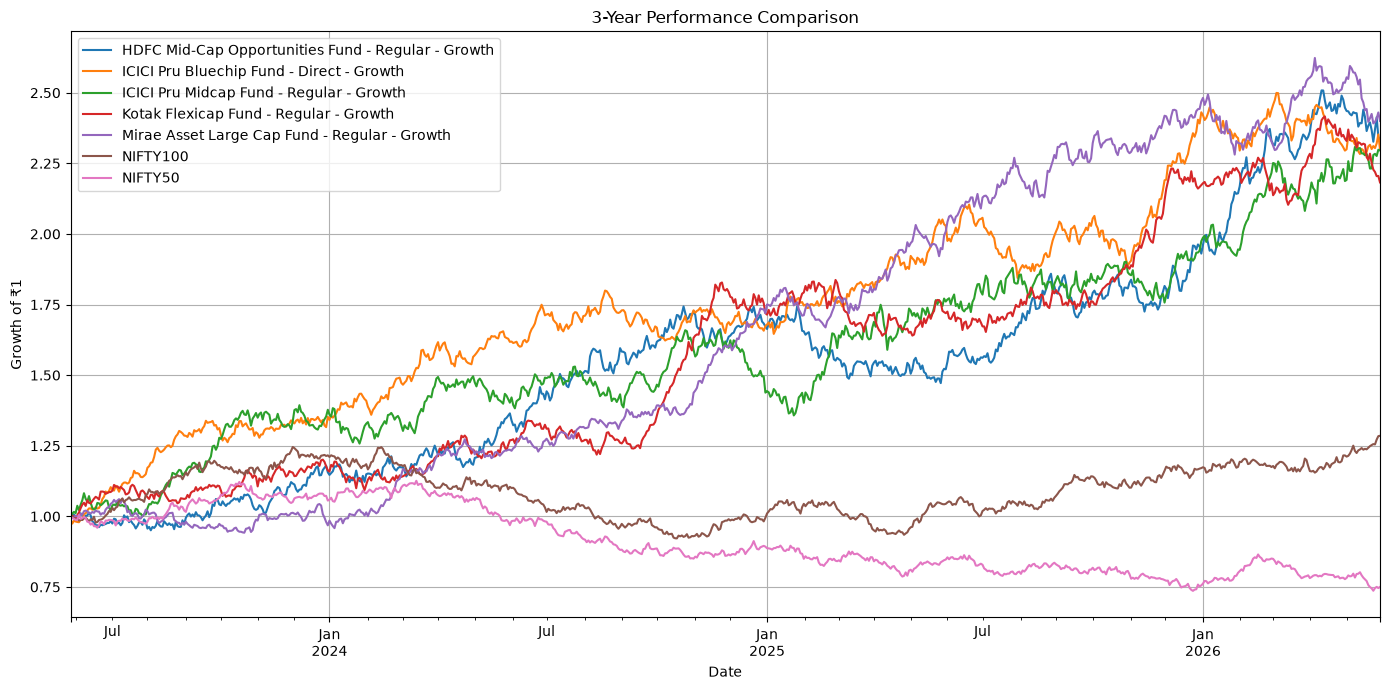

In [48]:
import matplotlib.pyplot as plt
comparison.plot(figsize=(14,7))
plt.title("3-Year Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("../reports/benchmark_comparison_3yr.png")
plt.show()